# Model Comparison Heatmap — FWI vs Climate Drivers
Compares Pearson r across models using pre-computed cached data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.ticker
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from scipy.stats import pearsonr

In [3]:
# ── Cache directories ────────────────────────────────────────────────────────
BASE = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src")

CACHE = {
    "GFDL-ESM4"          : BASE / "GFDL_ESM4/computed_means_GFDL-ESM4",
    "GFDL\nESM4"         : BASE / "GFDL_ESM4/computed_means_GFDL-ESM4",
    "MRI-ESM2-0 (hurs)"  : BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2-0 (Avg Hum)": BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2\nAvg Hum"       : BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2-0 (hursmin)": BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
    "MRI-ESM2-0 (Min Hum)" : BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
    "MRI-ESM2\nMin Hum"       : BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
}

# humidity variable name per model
HUM_VAR = {
    "GFDL-ESM4"           : "hurs",
    "GFDL\nESM4"          : "hurs",
    "MRI-ESM2-0 (hurs)"   : "hurs",
    "MRI-ESM2-0 (Avg Hum)" : "hurs",
    "MRI-ESM2\nAvg Hum"        : "hurs",
    "MRI-ESM2-0 (hursmin)": "hursmin",
    "MRI-ESM2-0 (Min Hum)" : "hursmin",
    "MRI-ESM2\nMin Hum"        : "hursmin",
}

# Unit conversions
UNIT = {
    "tasmax" : lambda x: x - 273.15,
    "pr"     : lambda x: x * 86_400.0,
    "sfcWind": lambda x: x,
    "hum"    : lambda x: x,
}

In [4]:
def load_model(cache_dir: Path, hum_var: str, scenarios: list) -> dict:
    """Load fwi + 4 drivers for given scenarios. Returns dict {var: {scen: da}}."""
    data = {}
    vars_to_load = ["fwi", "tasmax", "pr", "sfcWind", hum_var]
    for v in vars_to_load:
        key = "hum" if v == hum_var and v.startswith("hurs") else v
        data[key] = {}
        for s in scenarios:
            fp = cache_dir / f"{v}_{s}.nc"
            if fp.exists():
                data[key][s] = xr.open_dataarray(fp).load()
    return data

In [5]:
# ── Matplotlib-style heatmap helpers ─────────────────────────────────────────

def heatmap(data, row_labels, col_labels, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    if ax is None:
        ax = plt.gca()
    if cbar_kw is None:
        cbar_kw = {}
    im   = ax.imshow(data, **kwargs)
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_linewidth(0.5)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticklabels(row_labels,  fontsize=9)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(len(col_labels) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(row_labels)  + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"),
                     threshold=0.5, **textkw):
    if data is None:
        data = im.get_array()
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)
    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val   = data[i, j]
            color = textcolors[1] if abs(val) > threshold else textcolors[0]
            text  = im.axes.text(j, i, valfmt(val, None), color=color, **kw)
            texts.append(text)
    return texts

In [6]:
def plot_model_comparison_heatmap(
    model_names: list,
    scenarios:   list,
    title:       str,
    filename:    str,
    hum_label:   str   = "Humidity",
    figsize:     tuple = (5.51, 3.5),
    model_keys:  list  = None,
) -> None:
    # model_keys = cache lookup keys; model_names = display labels
    if model_keys is None:
        model_keys = model_names
    """
    4-row × 2-col heatmap: rows = variables, cols = models.
    Each cell = mean Pearson r across scenarios.
    """
    var_order  = ["tasmax", "pr", "sfcWind", "hum"]
    var_labels = ["Max\nTemp", "Precip", "Wind", hum_label]

    matrix = np.full((4, len(model_names)), np.nan)

    for col_i, (mname, mkey) in enumerate(zip(model_names, model_keys)):
        mdata = load_model(CACHE[mkey], HUM_VAR[mkey], scenarios)
        fwi_d = mdata["fwi"]

        for row_i, var in enumerate(var_order):
            drv_d = mdata.get(var, {})
            rs = []
            for s in scenarios:
                if s not in fwi_d or s not in drv_d:
                    continue
                fwi_da = fwi_d[s]
                drv_da = drv_d[s]
                t      = fwi_da["year"]
                fwi_v  = fwi_da.values
                drv_v  = UNIT[var](drv_da.sel(year=t, method="nearest")).values
                mask   = np.isfinite(fwi_v) & np.isfinite(drv_v)
                if mask.sum() > 2:
                    r, _ = pearsonr(fwi_v[mask], drv_v[mask])
                    rs.append(r)
            if rs:
                matrix[row_i, col_i] = np.mean(rs)

    df = pd.DataFrame(matrix, index=var_labels, columns=model_names)

    fig, ax = plt.subplots(figsize=figsize)

    def _fmt(x, pos):
        return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")

    im, _ = heatmap(
        df.values, var_labels, model_names, ax=ax,
        cmap="RdBu_r", vmin=-1, vmax=1,
        cbar_kw=dict(shrink=0.8, fraction=0.046, pad=0.04,
                     ticks=[-1, -0.5, 0, 0.5, 1]),
        cbarlabel="Pearson correlation (r)",
    )
    annotate_heatmap(im, data=df.values,
                     valfmt=matplotlib.ticker.FuncFormatter(_fmt),
                     size=9, threshold=0.5,
                     textcolors=("black", "white"))

    ax.set_title(title, pad=20, fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

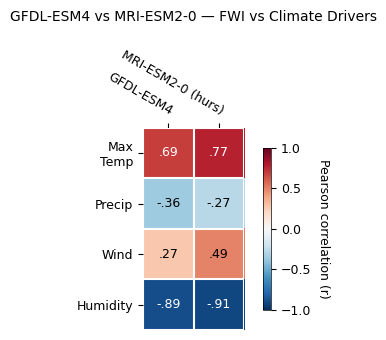

Saved: comparison_GFDL_vs_MRI_hurs.png


In [7]:
# ── Heatmap 1: GFDL-ESM4 vs MRI-ESM2-0 (hurs) ───────────────────────────────
COMMON_SCENARIOS_1 = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

plot_model_comparison_heatmap(
    model_names = ["GFDL-ESM4", "MRI-ESM2-0 (hurs)"],
    scenarios   = COMMON_SCENARIOS_1,
    title       = "GFDL-ESM4 vs MRI-ESM2-0 — FWI vs Climate Drivers",
    filename    = "comparison_GFDL_vs_MRI_hurs.png",
    hum_label   = "Humidity",
)

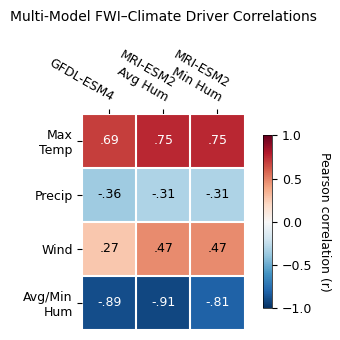

Saved: comparison_all_models.png


In [44]:
# ── Heatmap 2: All 3 models ───────────────────────────────────────────────────
# Uses all available scenarios per model (missing files are skipped automatically)
ALL_SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370",
                 "ssp460", "ssp534", "ssp585"]

plot_model_comparison_heatmap(
    model_names = ["GFDL-ESM4", "MRI-ESM2\nAvg Hum", "MRI-ESM2\nMin Hum"],
    scenarios   = ALL_SCENARIOS,
    title       = "Multi-Model FWI–Climate Driver Correlations",
    filename    = "comparison_all_models.png",
    hum_label   = "Avg/Min\nHum",
    figsize     = (5.51, 3.5),
)

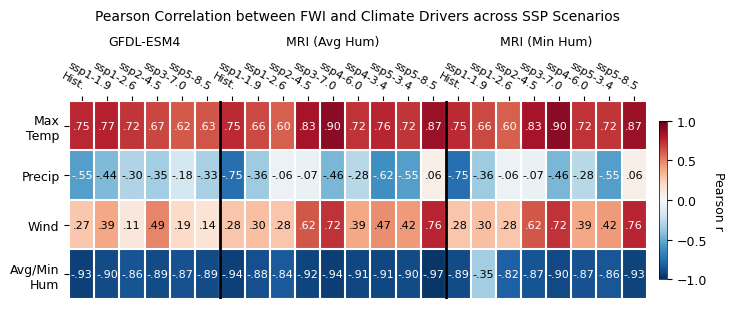

Saved: comparison_merged_heatmap.png


In [40]:
# ── Single merged heatmap: rows=variables, cols=scenarios grouped by model ────
# Journal spec (Weather and Climate Extremes / Elsevier):
#   full double-column width = 190 mm = 7.48 in  |  min font = 8 pt  |  300 DPI

SCENARIO_LABELS = {
    "historical": "Hist.",
    "ssp119": "ssp1-1.9", "ssp126": "ssp1-2.6", "ssp245": "ssp2-4.5",
    "ssp370": "ssp3-7.0", "ssp460": "ssp4-6.0", "ssp434": "ssp4-3.4",
    "ssp534": "ssp5-3.4", "ssp585": "ssp5-8.5",
}

MODEL_CONFIGS = [
    dict(key="GFDL-ESM4",            label="GFDL-ESM4",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp585"]),
    dict(key="MRI-ESM2-0 (hurs)",    label="MRI (Avg Hum)",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp460","ssp434","ssp534","ssp585"]),
    dict(key="MRI-ESM2-0 (hursmin)", label="MRI (Min Hum)",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp460","ssp534","ssp585"]),
]

VAR_ORDER  = ["tasmax", "pr", "sfcWind", "hum"]
VAR_LABELS = ["Max\nTemp", "Precip", "Wind", "Avg/Min\nHum"]

# ── Build full matrix ─────────────────────────────────────────────────────────
all_col_labels = []
group_sizes    = []
full_matrix    = np.full((4, 0), np.nan)

for cfg in MODEL_CONFIGS:
    mdata  = load_model(CACHE[cfg["key"]], HUM_VAR[cfg["key"]], cfg["scenarios"])
    fwi_d  = mdata["fwi"]
    block  = np.full((4, len(cfg["scenarios"])), np.nan)

    for row_i, var in enumerate(VAR_ORDER):
        drv_d = mdata.get(var, {})
        for col_i, s in enumerate(cfg["scenarios"]):
            if s not in fwi_d or s not in drv_d:
                continue
            fwi_v = fwi_d[s].values
            drv_v = UNIT[var](drv_d[s].sel(year=fwi_d[s]["year"], method="nearest")).values
            mask  = np.isfinite(fwi_v) & np.isfinite(drv_v)
            if mask.sum() > 2:
                from scipy.stats import pearsonr
                r, _ = pearsonr(fwi_v[mask], drv_v[mask])
                block[row_i, col_i] = r

    all_col_labels += [SCENARIO_LABELS.get(s, s) for s in cfg["scenarios"]]
    group_sizes.append(len(cfg["scenarios"]))
    full_matrix = np.hstack([full_matrix, block])

# ── Plot ──────────────────────────────────────────────────────────────────────
FIG_W, FIG_H = 7.48, 3.2

n_cols  = full_matrix.shape[1]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

im = ax.imshow(full_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

cbar = fig.colorbar(im, ax=ax, shrink=0.8, fraction=0.025, pad=0.02,
                    ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.set_ylabel("Pearson r", rotation=-90, va="bottom", fontsize=9)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.5)

ax.set_xticks(range(n_cols))
ax.set_xticklabels(all_col_labels, fontsize=8)
ax.set_yticks(range(4))
ax.set_yticklabels(VAR_LABELS, fontsize=9)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(n_cols + 1) - .5, minor=True)
ax.set_yticks(np.arange(5) - .5, minor=True)
ax.grid(which="minor", color="w", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

def _fmt(x, pos):
    return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")
fmt = matplotlib.ticker.FuncFormatter(_fmt)
for i in range(4):
    for j in range(n_cols):
        val = full_matrix[i, j]
        if np.isfinite(val):
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, fmt(val, None), ha="center", va="center",
                    color=color, fontsize=8)

# Model group dividers (thick white line) + labels
x_pos = -0.5
for cfg, size in zip(MODEL_CONFIGS, group_sizes):
    mid = x_pos + size / 2
    ax.text(mid, -1.7, cfg["label"], ha="center", va="center",
            fontsize=9, transform=ax.transData)
    x_pos += size
    if x_pos < n_cols - 0.5:
        ax.axvline(x=x_pos, color="black", linewidth=2, zorder=3)

ax.set_title("Pearson Correlation between FWI and Climate Drivers across SSP Scenarios", pad=28, fontsize=10)

plt.tight_layout()
plt.savefig("comparison_merged_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: comparison_merged_heatmap.png")